### Project Summary 

### Project Objective 
- Telecom Users allocation that prone to churn

### Project Tasks 
**1) Descriptive data analysis:**

- Data Description: signs, size, identification of patterns and structure in the data.

**2) Feature Selection:**

- Determine the relevant features to classify users who will "leave" or "stay"

**3) Data Preprocessing:**

- Determine the best way to process features (imuters, categorical encoders) and a method to solve the problem with class imbalance (Random Over/Undersampling, SMOTE and others)

**4) Selecting and Building a model**

- Determine the model that would best cope with the stated objective of the project.

**5) Model Optimization**

- Select the optimal hyperparameters of the model, providing the best quality of classification

### Project Metrics
- The main metric: `ROC-AUC`
- Auxiliary metrics: `Precision` and `Recall` to track `False Positive` and `False Negative` and `F1-Score`

Model quality was being checked by using `StratifiedCrossValidation (n_folds = 5)`

### Project Pipeline
The main `Pipeline` for feature processing looked like this:

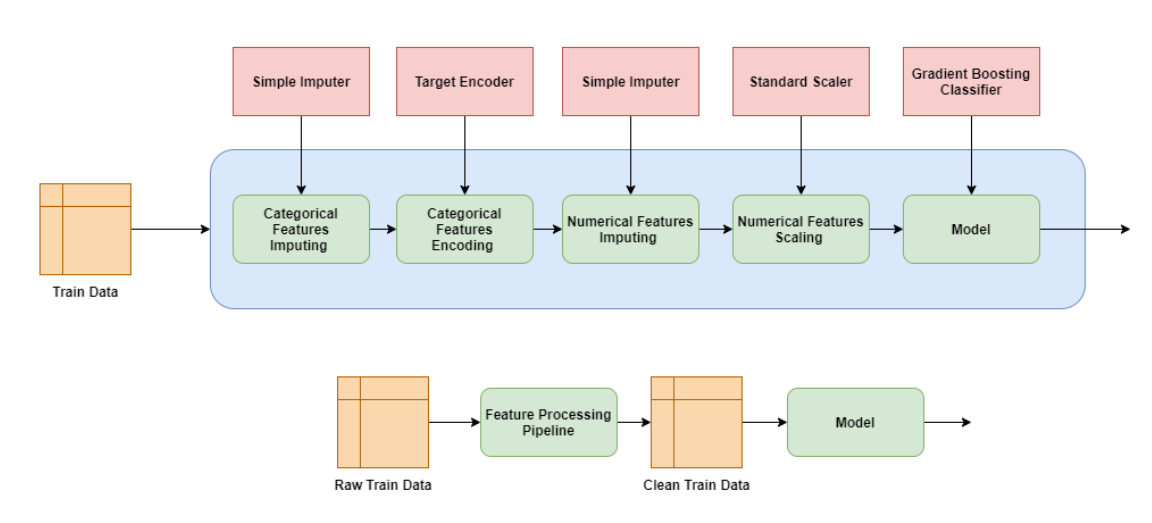

The missing values for numeric and categorical features was carried out using `SimpleImputer`:
- Categorical features: `SimpleImputer (strategy = 'constant', fill_value = 'unknown')`
- Numerical traits: `SimpleImputer (strategy = 'mean')`

Categorical features encoding and scaling numeric:
- `StandardScaler ()`
- `TargetEncoder ()`

All preprocessing elements were cross-validated. In the final solution, these elements were used, since they provided the greatest growth of the `ROC-AUC` metric. The selection of features took place outside the `Pipeline`. This `Pipeline` already accepts the final sample (i.e. after the stage of feature selection).

### Initial Feature Selection
It should be said that there were a lot of missing values in the dataset. The first step was to identify features that entirely consisted of missing values, such features were excluded from consideration. Further, for each feature, the share of missing values varied greatly. The following histograms were built to visualize the proportion of missing values.

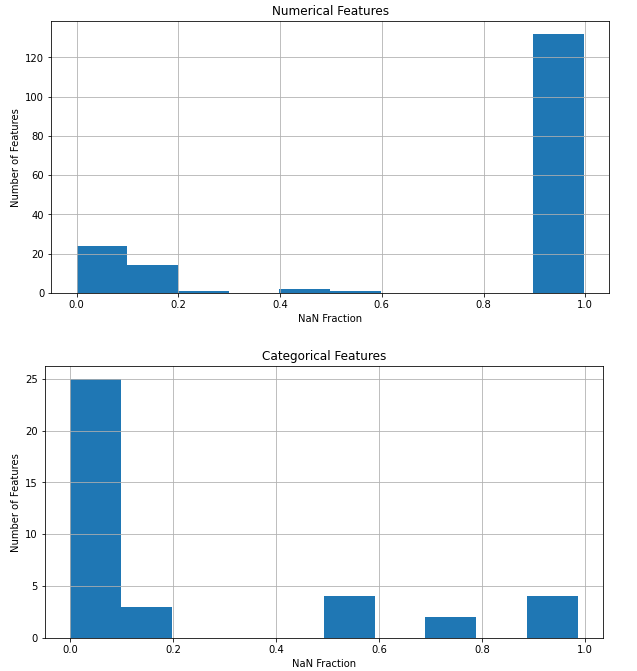

It was decided that features with a NaN ratio of more than 90% are excluded, since we are unlikely to be able to recover these dependencies. This made it possible to exclude a fairly large number of numerical features and a few categorical ones. The remaining features fell into further analysis.

Categorical and numerical features was selected separately. For these features, a number of methods were chosen to assess the relationship of features with the target variable:
- Categorical features: V-Krammer value
- Numerical features: Chi-square value

The calculated values were used to determine the top features. Since there were few of them, it was decided to iteratively add these features to the model, build it on the current set of features and assess the quality. The following results were obtained.

### Numeric Features

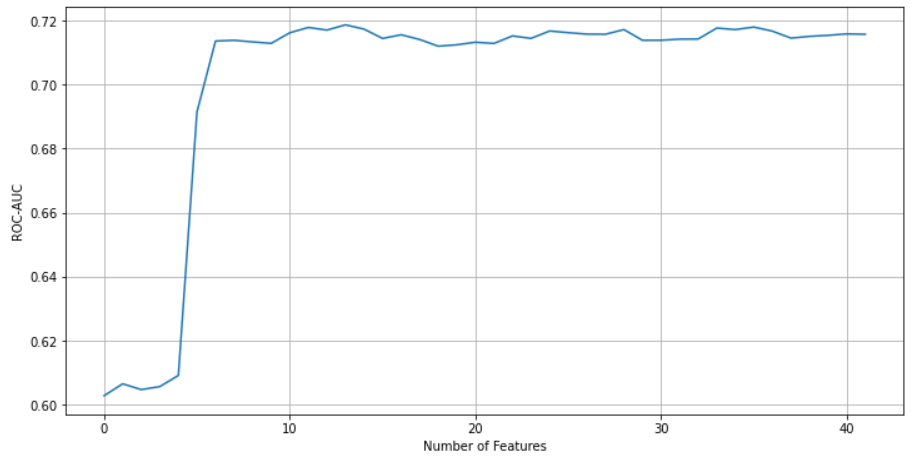

It can be seen that the first top 15 features by correlation with the target provide an increase in quality, then the quality stops growing. Given this fact, the first 15 were selected.

### Categorical Features
These features were selected  similarly

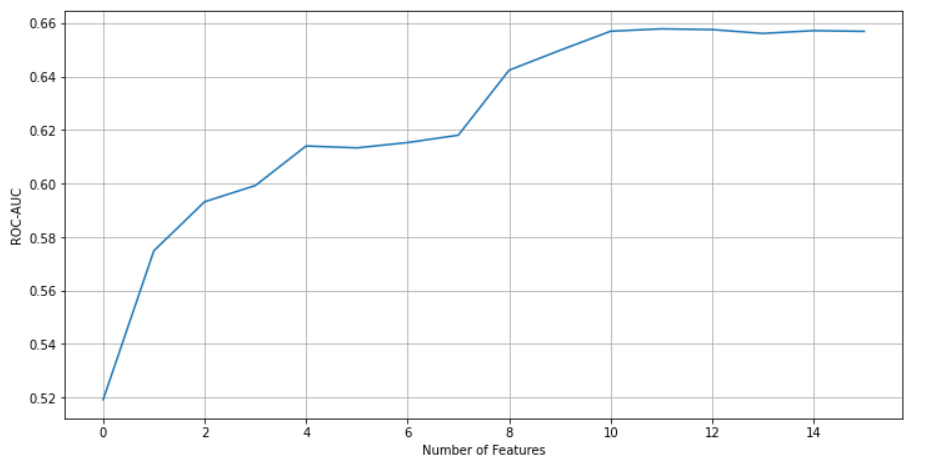

### Low Dispersion Features
The `BoxPlot` of numerical features was analyzed where it was found that the features `Var143 Var173 Var35 Var132` differ little from zero. The exclusion of these features led to an increase in the target metric.

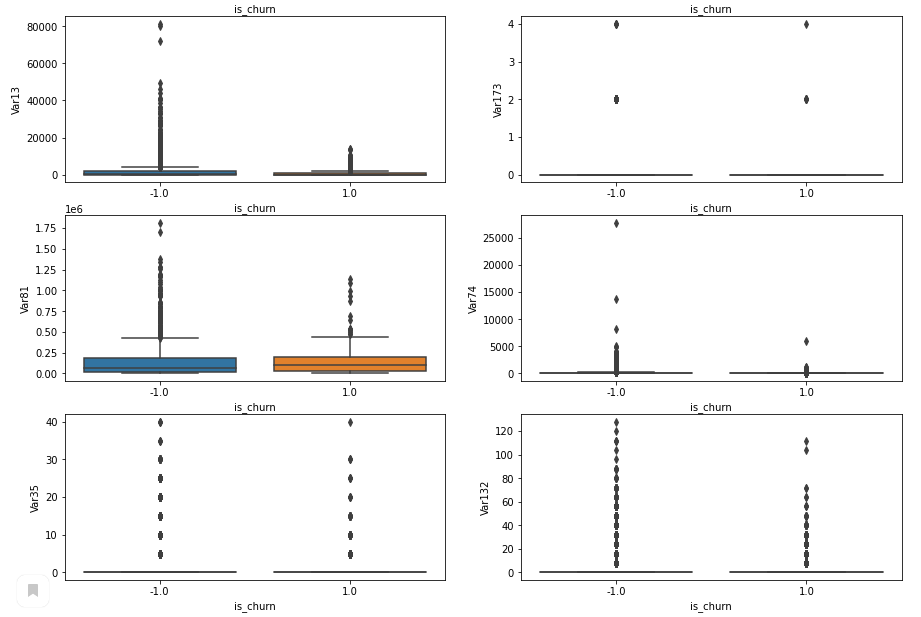

### Learning Curves
At the initial stage, it was necessary to find out if there is enough data for our model and how the model copes with the classification. For this purpose, validation curves were built. Without feature selection "as is", the model had a problem with `High Variance`. To further improve the quality of the model, it would be necessary:
- Collect more data (which is impossible)
- Simplify the model, coduct feature selection

This is how the learning curves looked like without feature selection.

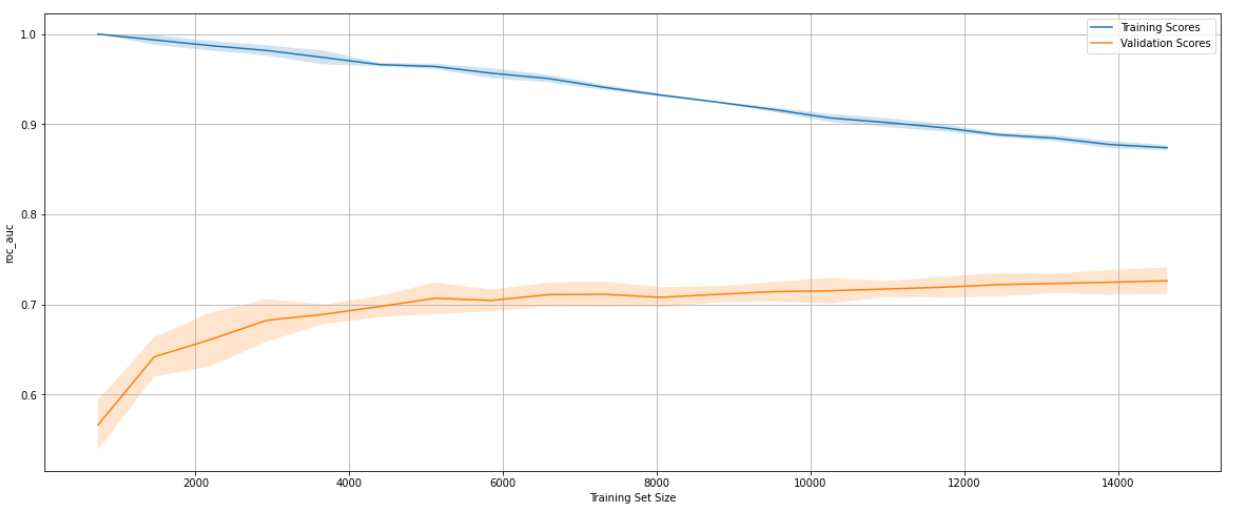

After feature selection, the learning curves improved slightly, indicating correct feature selection.

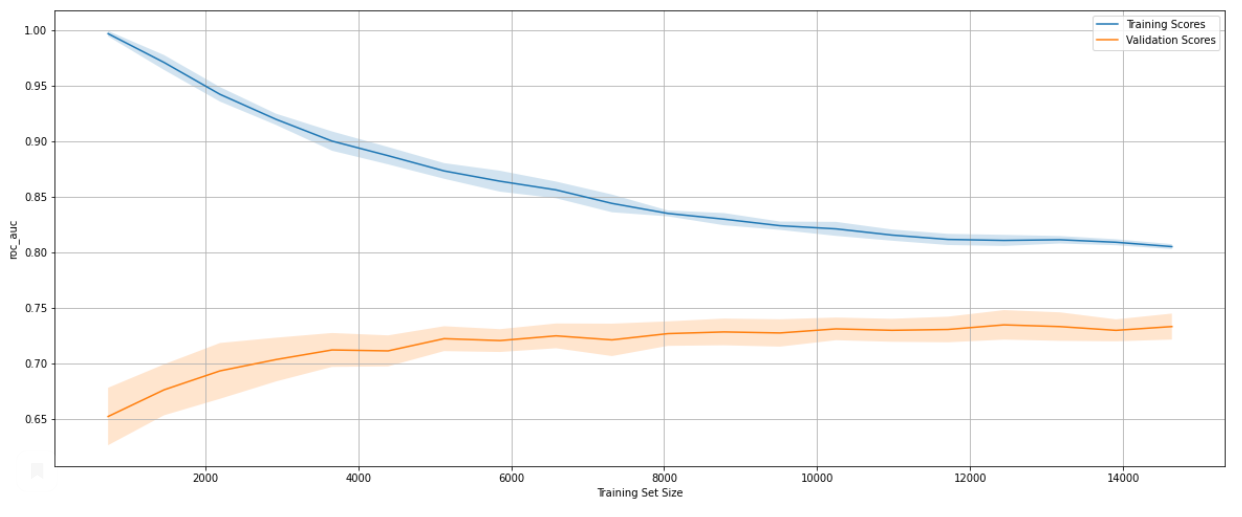

The quality on these features was `ROC-AUC: 0.734913`

### Position of Objects in Feature Space and Outliers
It was also interesting to know how our objects are located in the feature space:
- Are there many outliers?
- Are classes separable well?

This is how the objects looked before feature selection:

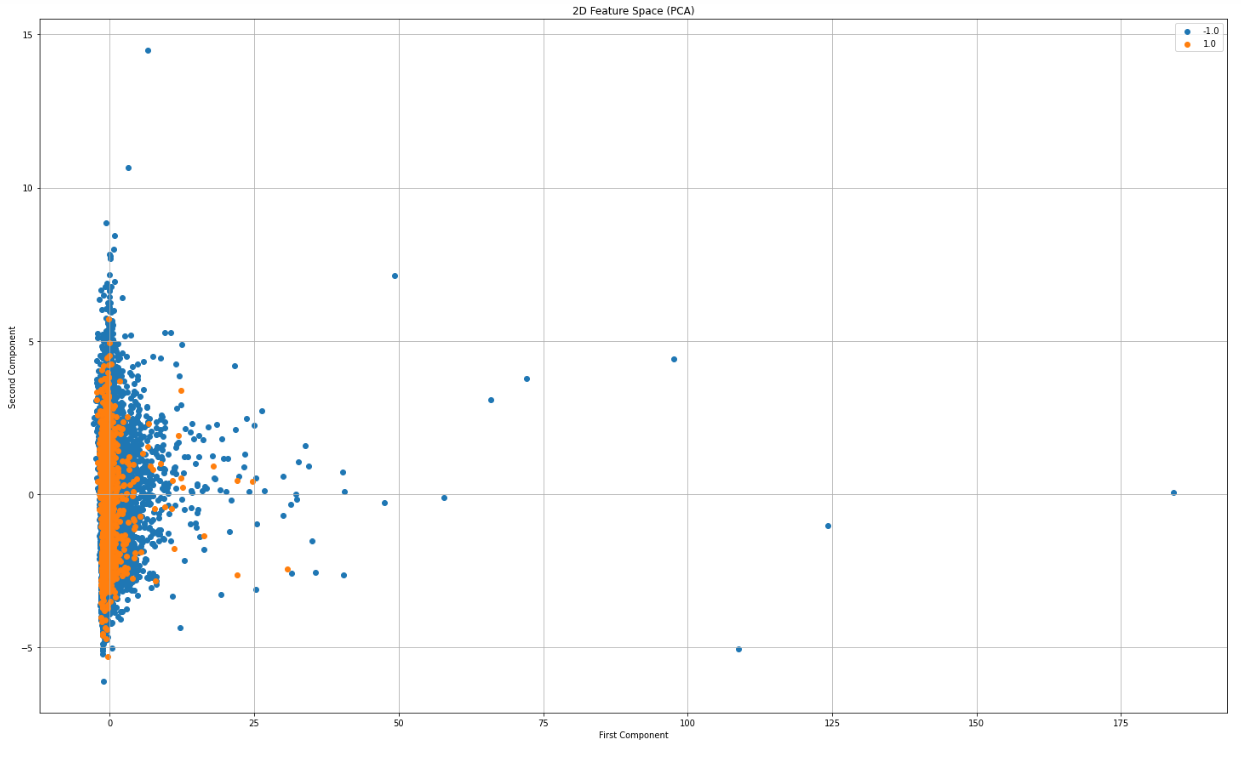

You can see that there are outliers and the classes are strongly mixed with each other. After selection, we see a different picture:

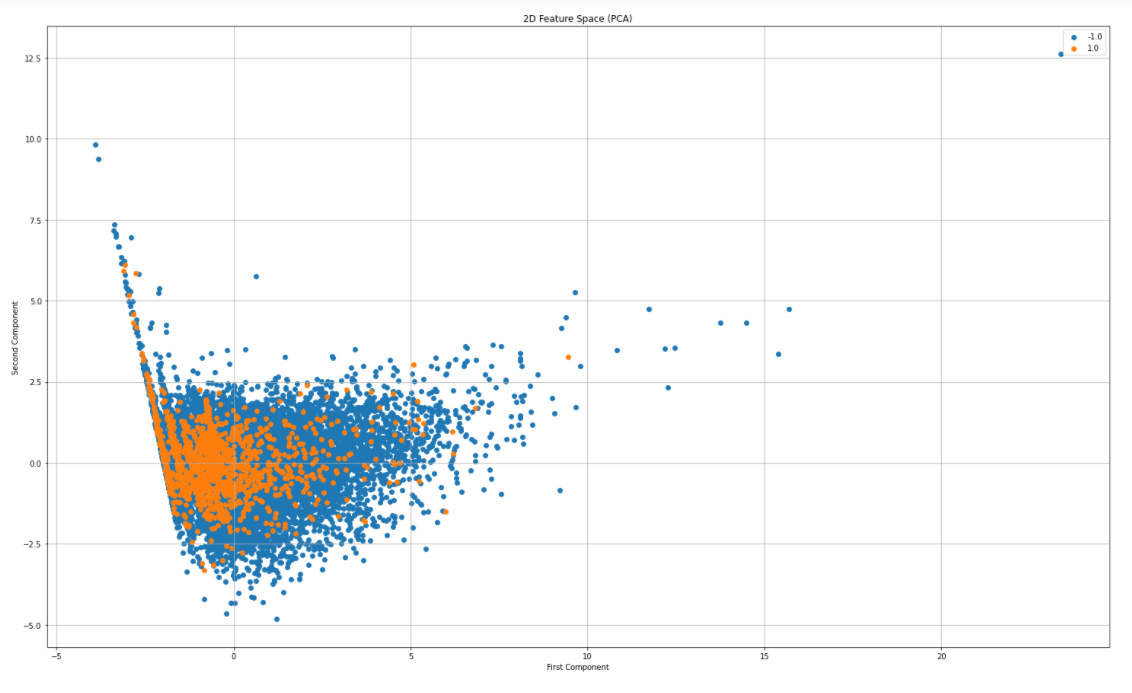

It is noticeable that the outliers have not gone anywhere. Experiments were carried out to eliminate outliers. Removing such observations from training led to a sharp drop in quality; an experiment was also conducted to replace such observations with an average one, for example. The quality decreased slightly, but not significantly `ROC-AUC: 0.733`. And the objects themselves in space took the following position:

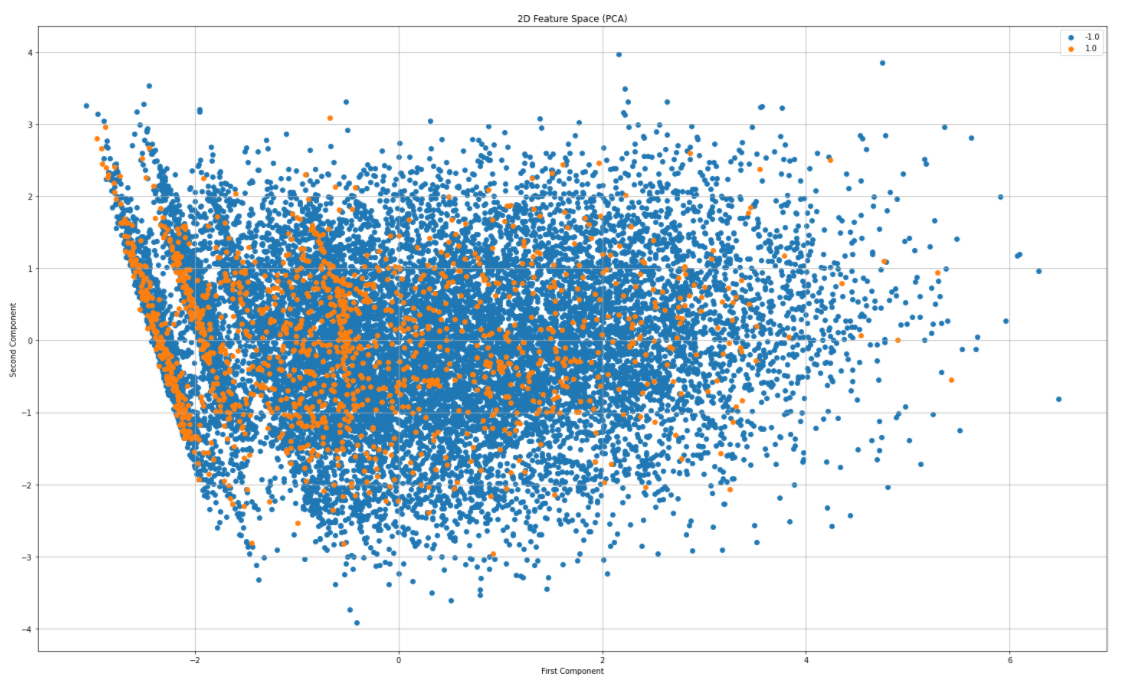

### Dealing with Class Imbalances
The dataset is unbalanced. Class Ratio `{-1.0: 0.924746, 1.0: 0.075254}`

The following **Undersampling** methods were used:
- Random Undersampling
- One-Sided Selection
- Under-Sampling with Cluster Centroids
- Nearmiss 1 & 2 & 3

The following **Oversampling** methods were used:
- Random Oversampling
- SMOTE (Synthetic Minority Oversampling Technique) (likely to be bad)
- ADASYN (Adaptive Synthetic Sampling Approach)
- Combination SMOTE + Tomek Links

These methods could not radically improve the situation. Three candidates were selected as the main ones:
- Assigning weights to observations (`F1-Score: 0.282003`,` ROC-AUC: .733730`)
- Random Oversampling (`F1-Score: 0.647494`,` ROC-AUC: 0.774711`)
- Random Undersampling (`F1-Score: 0.284221`,` ROC-AUC: 0.733171`)

Random Oversampling was not used in the final solution, as there was a risk of overfitting due to duplicate objects. Finally, 
th method : `Setting weights for observations (more reliable)` was applied.

### Feature Importances 
In the final decision, it was interesting to look at the importance of the features for the model.

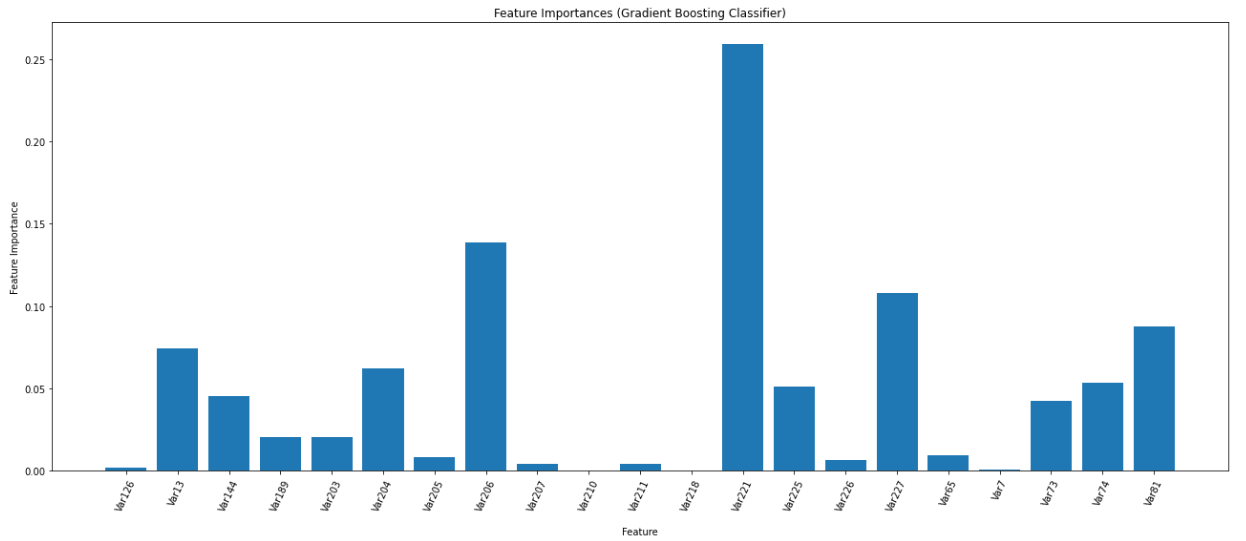

Almost all of the selected features are important for the model. The top 3 most important features are categorical features.

### Model Hyperparameters
The selection of model hyperparameters was carried out using the Bayesian approach, using the module `HyperOpt`. The number of parameters for the model is large, so using the standard `GridSearchCV` would be very time consuming. The hyperparameter tweak only slightly improved the quality. The quality of the final solution was `ROC-AUC: 0.7364 (CV)`